# Unlocking Societal Trends in Aadhaar Enrollment and Updates

This notebook performs an end-to-end exploratory and analytical study on Aadhaar
demographic and biometric update data.

The objective is to:
- Clean and consolidate raw datasets
- Identify meaningful trends and anomalies
- Support downstream risk intelligence and policy insights


### Hackathon Evaluation Alignment

This notebook focuses on **Data Analysis & Insights**, covering:

- Univariate,temporal trend,bivariate,trivariate analysis
- Regional and behavioral patterns in Aadhaar updates
- Actionable insights supporting administrative decision-making


## 1️⃣ Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")


## 1. Loading Raw Aadhaar Datasets

We load **all biometric\*** and **demographic\*** CSV files from the data folder.
This allows scalable analysis when new files are added.


In [2]:
def load_prefixed_files(folder_path, prefix):
    dfs = []
    for file in os.listdir(folder_path):
        if file.lower().startswith(prefix) and file.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder_path, file))
            df["source_file"] = file
            dfs.append(df)

    if not dfs:
        raise ValueError(f"No files found with prefix '{prefix}' in {folder_path}")

    return pd.concat(dfs, ignore_index=True)


DATA_FOLDER = "../data"

biometric_df = load_prefixed_files(DATA_FOLDER, "biometric")
demographic_df = load_prefixed_files(DATA_FOLDER, "demographic")

print("Biometric rows:", biometric_df.shape)
print("Demographic rows:", demographic_df.shape)


Biometric rows: (1861108, 7)
Demographic rows: (2071700, 7)


## 2. Date Parsing and Cleaning

Aadhaar datasets often contain mixed date formats.
We safely parse dates and drop invalid entries.


In [3]:
biometric_df["date"] = pd.to_datetime(
    biometric_df["date"], errors="coerce", dayfirst=True
)

demographic_df["date"] = pd.to_datetime(
    demographic_df["date"], errors="coerce", dayfirst=True
)

biometric_df = biometric_df.dropna(subset=["date"])
demographic_df = demographic_df.dropna(subset=["date"])

print("Valid biometric rows:", biometric_df.shape)
print("Valid demographic rows:", demographic_df.shape)


Valid biometric rows: (1861108, 7)
Valid demographic rows: (2071700, 7)


## 3. Data Pre-Processing Layer

We merge biometric and demographic datasets using:
- date
- state
- district
- pincode

This creates a **unified view of Aadhaar update behavior**.


In [4]:
df = pd.merge(
    biometric_df,
    demographic_df,
    on=["date", "state", "district", "pincode"],
    suffixes=("_bio", "_demo"),
    how="inner"
)

df = df.sort_values(["pincode", "date"])
df.reset_index(drop=True, inplace=True)

df.head()


,date,state,district,pincode,bio_age_5_17,bio_age_17_,source_file_bio,demo_age_5_17,demo_age_17_,source_file_demo
0,2025-03-01,Delhi,New Delhi,110001,181,159,biometric1.csv,74,437,demographic3.csv
1,2025-03-01,Delhi,New Delhi,110001,181,159,biometric1.csv,74,437,demographic5.csv
2,2025-06-01,Delhi,New Delhi,110001,121,164,biometric1.csv,44,321,demographic3.csv
3,2025-09-01,Delhi,New Delhi,110001,6,4,biometric1.csv,1,10,demographic5.csv
4,2025-09-01,Delhi,Central Delhi,110001,0,2,biometric1.csv,1,3,demographic1.csv


## 4. State Name Standardization

The dataset contains multiple spellings and formats for Indian states/UTs.
We canonicalize them to ensure clean aggregation and accurate analysis.


In [5]:
INDIA_STATE_CANONICAL = {
    "andhra pradesh": "Andhra Pradesh",
    "arunachal pradesh": "Arunachal Pradesh",
    "assam": "Assam",
    "bihar": "Bihar",
    "jharkhand": "Jharkhand",
    "chhattisgarh": "Chhattisgarh",
    "madhya pradesh": "Madhya Pradesh",
    "gujarat": "Gujarat",
    "maharashtra": "Maharashtra",
    "goa": "Goa",
    "rajasthan": "Rajasthan",
    "karnataka": "Karnataka",
    "kerala": "Kerala",
    "tamil nadu": "Tamil Nadu",
    "telangana": "Telangana",
    "odisha": "Odisha",
    "orissa": "Odisha",
    "west bengal": "West Bengal",
    "westbengal": "West Bengal",
    "delhi": "Delhi",
    "nct of delhi": "Delhi",
    "chandigarh": "Chandigarh",
    "ladakh": "Ladakh",
    "lakshadweep": "Lakshadweep",
    "jammu & kashmir": "Jammu & Kashmir",
    "jammu and kashmir": "Jammu & Kashmir",
    "andaman & nicobar islands": "Andaman & Nicobar Islands",
    "andaman and nicobar islands": "Andaman & Nicobar Islands",
    "puducherry": "Puducherry",
    "pondicherry": "Puducherry",
    "dadra & nagar haveli and daman & diu": "Dadra & Nagar Haveli and Daman & Diu",
    "daman & diu": "Dadra & Nagar Haveli and Daman & Diu"
}

def canonicalize_state(state):
    if pd.isna(state):
        return state
    s = str(state).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return INDIA_STATE_CANONICAL.get(s, s.title())

df["state"] = df["state"].apply(canonicalize_state)

print("Unique states:", df["state"].nunique())
sorted(df["state"].unique())


Unique states: 41


['Andaman & Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra & Nagar Haveli',
 'Dadra & Nagar Haveli and Daman & Diu',
 'Dadra And Nagar Haveli',
 'Dadra And Nagar Haveli And Daman And Diu',
 'Daman And Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu & Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bangal',
 'West Bengal']

## 5. Feature Engineering

We derive meaningful indicators to analyze behavior:
- Total biometric updates
- Total demographic updates
- Ratio of biometric to demographic activity


In [6]:
df["biometric_total"] = df["bio_age_5_17"] + df["bio_age_17_"]
df["demographic_total"] = df["demo_age_5_17"] + df["demo_age_17_"]

df["bio_demo_ratio"] = df["biometric_total"] / (df["demographic_total"] + 1)

df[["biometric_total", "demographic_total", "bio_demo_ratio"]].describe()


,biometric_total,demographic_total,bio_demo_ratio
count,1.618215e+06,1.618215e+06,1.618215e+06
mean,2.623479e+01,2.819497e+01,1.252548e+00
std,1.350303e+02,1.557307e+02,1.616490e+00
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.000000e+00,3.000000e+00,4.615385e-01
50%,8.000000e+00,8.000000e+00,8.333333e-01
75%,2.000000e+01,2.000000e+01,1.500000e+00
max,1.338100e+04,1.694200e+04,1.665000e+02


## 6. Univariate Analysis

We examine distributions of biometric and demographic updates
to understand baseline behavior.


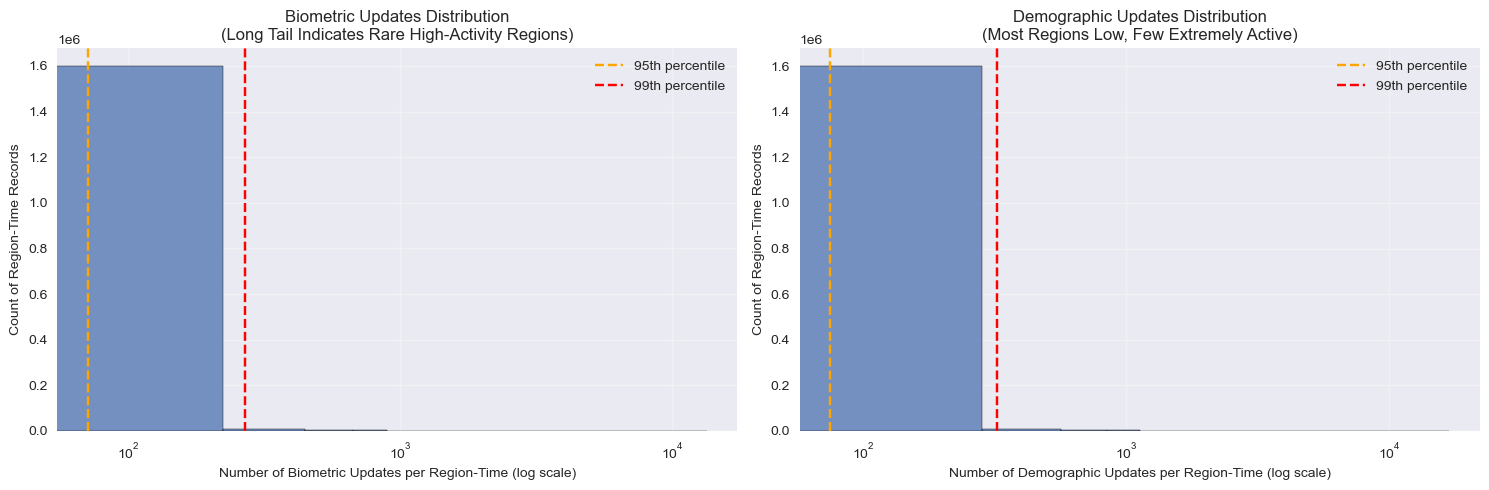

In [7]:
import numpy as np

# Percentile thresholds (for interpretation)
bio_p95 = df["biometric_total"].quantile(0.95)
bio_p99 = df["biometric_total"].quantile(0.99)

demo_p95 = df["demographic_total"].quantile(0.95)
demo_p99 = df["demographic_total"].quantile(0.99)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# -----------------------------
# Biometric Updates
# -----------------------------
sns.histplot(
    df["biometric_total"],
    bins=60,
    ax=ax[0]
)

ax[0].set_xscale("log")
ax[0].axvline(bio_p95, color="orange", linestyle="--", label="95th percentile")
ax[0].axvline(bio_p99, color="red", linestyle="--", label="99th percentile")

ax[0].set_title(
    "Biometric Updates Distribution\n(Long Tail Indicates Rare High-Activity Regions)",
    fontsize=12
)
ax[0].set_xlabel(
    "Number of Biometric Updates per Region-Time (log scale)",
    fontsize=10
)
ax[0].set_ylabel(
    "Count of Region-Time Records",
    fontsize=10
)
ax[0].legend()
ax[0].grid(alpha=0.3)

# -----------------------------
# Demographic Updates
# -----------------------------
sns.histplot(
    df["demographic_total"],
    bins=60,
    ax=ax[1]
)

ax[1].set_xscale("log")
ax[1].axvline(demo_p95, color="orange", linestyle="--", label="95th percentile")
ax[1].axvline(demo_p99, color="red", linestyle="--", label="99th percentile")

ax[1].set_title(
    "Demographic Updates Distribution\n(Most Regions Low, Few Extremely Active)",
    fontsize=12
)
ax[1].set_xlabel(
    "Number of Demographic Updates per Region-Time (log scale)",
    fontsize=10
)
ax[1].set_ylabel(
    "Count of Region-Time Records",
    fontsize=10
)
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 📊 Key Observations from Update Distributions

- The distributions are **highly right-skewed**, meaning most regions record
  *very few updates* in a given time period.
- The **long tail on the right** represents a small number of regions with
  **exceptionally high update activity**.
- The **95th and 99th percentile lines** mark statistically rare behavior.
- Regions beyond these thresholds are **unusual compared to the national baseline**.

🔍 **Why this matters**:
- These rare high-activity regions form the **primary candidates for risk analysis**.
- The heavy-tailed structure justifies the use of **unsupervised anomaly detection**
  instead of fixed thresholds or rule-based systems.


## Temporal Trend Analysis

This section studies how Aadhaar update patterns evolve over time.
Temporal analysis helps identify long-term trends, sudden spikes, and
periods of abnormal activity that may not be visible in static analysis.


### Why Temporal Trends Matter

- Detects sudden surges or drops in updates  
- Helps identify policy-driven or operational changes  
- Provides early signals of abnormal or coordinated activity  


C:\Users\khage\AppData\Local\Temp\ipykernel_5964\3688595653.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")[["biometric_total", "demographic_total"]]


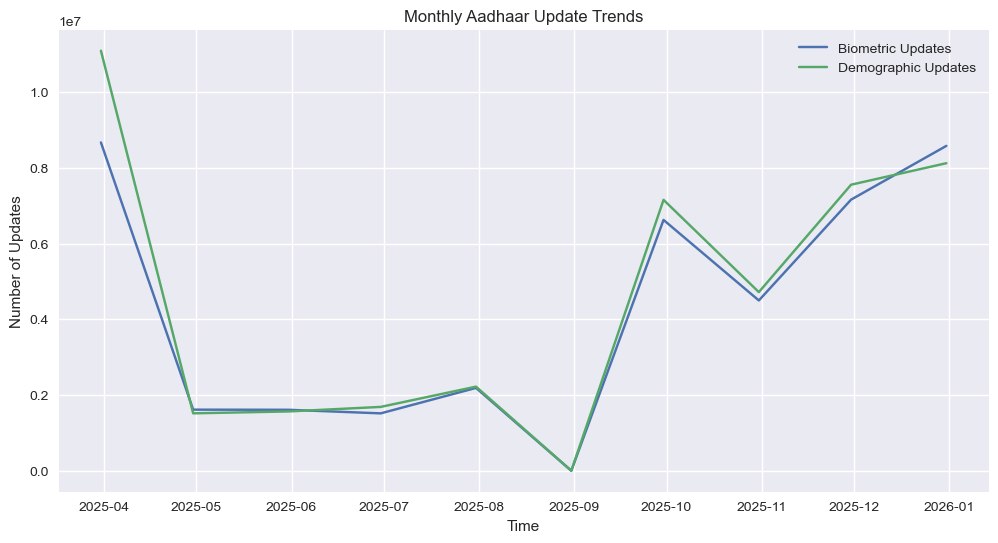

In [8]:
# Aggregate updates monthly
monthly_updates = (
    df
    .set_index("date")
    .resample("M")[["biometric_total", "demographic_total"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_updates["date"], monthly_updates["biometric_total"], label="Biometric Updates")
plt.plot(monthly_updates["date"], monthly_updates["demographic_total"], label="Demographic Updates")

plt.title("Monthly Aadhaar Update Trends")
plt.xlabel("Time")
plt.ylabel("Number of Updates")
plt.legend()
plt.grid(True)
plt.show()


**Insight:**  
This plot reveals how Aadhaar update activity changes over time.
Sudden spikes or prolonged increases may indicate operational anomalies,
mass update drives, or suspicious coordinated behavior.


C:\Users\khage\AppData\Local\Temp\ipykernel_5964\2761819412.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["bio_demo_ratio"]


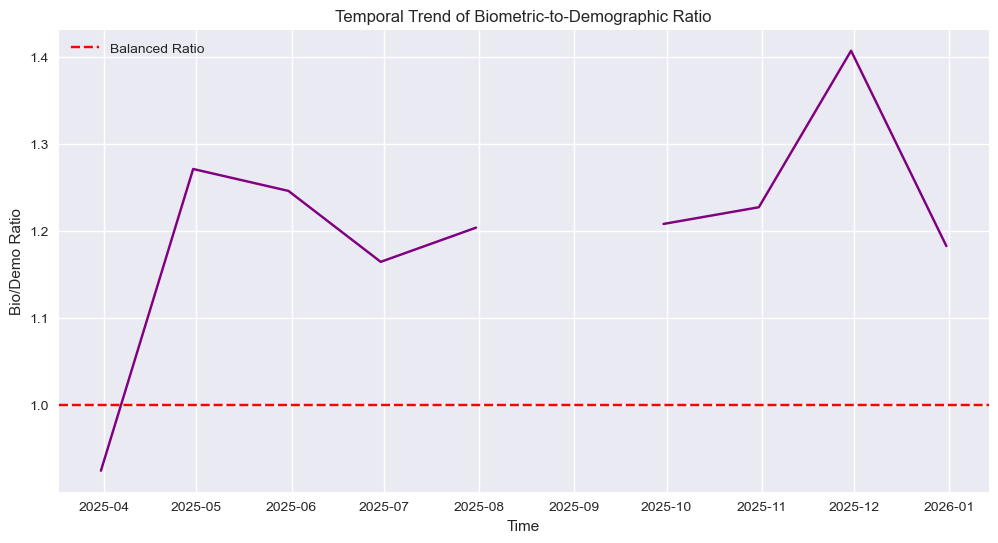

In [9]:
# Monthly biometric-to-demographic ratio
monthly_ratio = (
    df
    .set_index("date")
    .resample("M")["bio_demo_ratio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_ratio["date"], monthly_ratio["bio_demo_ratio"], color="purple")
plt.axhline(1, linestyle="--", color="red", label="Balanced Ratio")

plt.title("Temporal Trend of Biometric-to-Demographic Ratio")
plt.xlabel("Time")
plt.ylabel("Bio/Demo Ratio")
plt.legend()
plt.grid(True)
plt.show()


**Insight:**  
Periods where the biometric-to-demographic ratio remains consistently high
may indicate abnormal biometric activity concentration, warranting deeper
investigation in later analysis stages.


C:\Users\khage\AppData\Local\Temp\ipykernel_5964\2279017411.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")[[


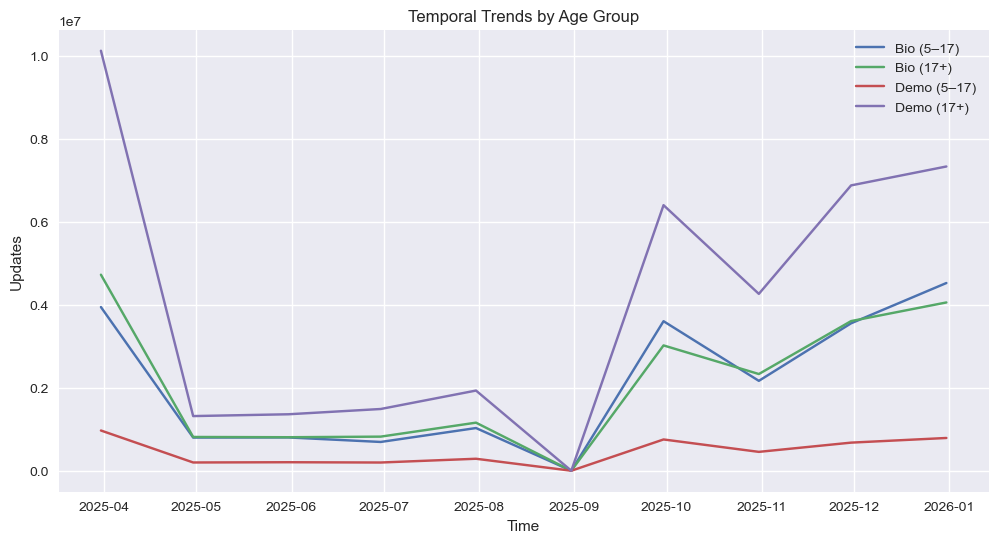

In [10]:
age_temporal = (
    df
    .set_index("date")
    .resample("M")[[
        "bio_age_5_17",
        "bio_age_17_",
        "demo_age_5_17",
        "demo_age_17_"
    ]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(age_temporal["date"], age_temporal["bio_age_5_17"], label="Bio (5–17)")
plt.plot(age_temporal["date"], age_temporal["bio_age_17_"], label="Bio (17+)")
plt.plot(age_temporal["date"], age_temporal["demo_age_5_17"], label="Demo (5–17)")
plt.plot(age_temporal["date"], age_temporal["demo_age_17_"], label="Demo (17+)")

plt.title("Temporal Trends by Age Group")
plt.xlabel("Time")
plt.ylabel("Updates")
plt.legend()
plt.grid(True)
plt.show()


**Insight:**  
Age-wise temporal patterns reveal which population segments contribute
most to update surges at different time periods, improving interpretability
of downstream risk scores.


## 7. Bivariate Analysis

We analyze how biometric and demographic updates interact.
Extreme deviations may indicate abnormal behavior.


C:\Users\khage\AppData\Local\Temp\ipykernel_5964\3476766739.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


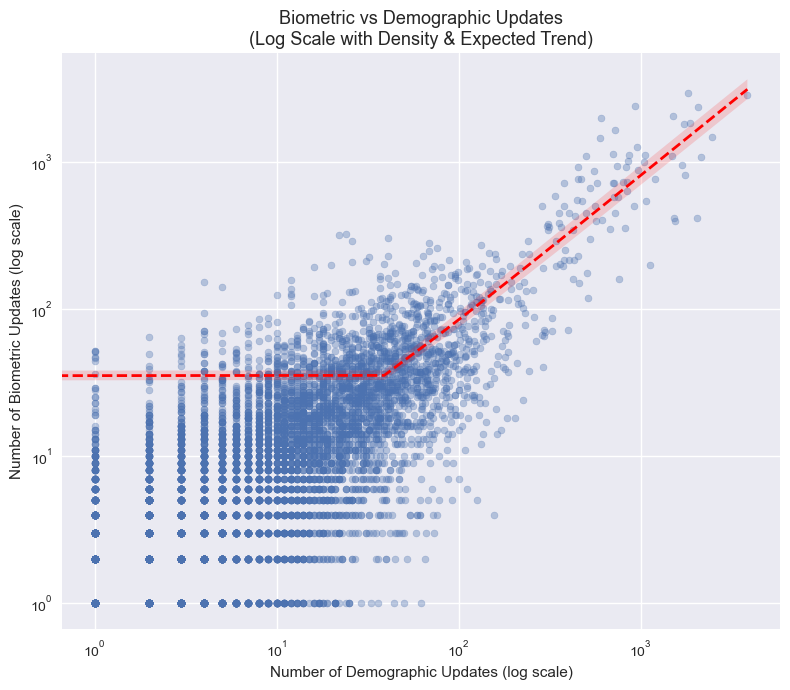

()

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Sample for clarity (large datasets get cluttered)
plot_df = df.sample(8000, random_state=42)

plt.figure(figsize=(8, 7))

# Density contours (shows normal behavior zone)
sns.kdeplot(
    data=plot_df,
    x="demographic_total",
    y="biometric_total",
    levels=5,
    color="gray",
    linewidths=1,
    alpha=0.6,
    log_scale=True
)

# Scatter points
sns.scatterplot(
    data=plot_df,
    x="demographic_total",
    y="biometric_total",
    alpha=0.35,
    s=25,
    edgecolor=None
)

# Regression / reference line (expected relationship)
sns.regplot(
    data=plot_df,
    x="demographic_total",
    y="biometric_total",
    scatter=False,
    color="red",
    line_kws={"linewidth": 2, "linestyle": "--"}
)

# Log scale for better visibility
plt.xscale("log")
plt.yscale("log")

# Labels & title
plt.xlabel("Number of Demographic Updates (log scale)", fontsize=11)
plt.ylabel("Number of Biometric Updates (log scale)", fontsize=11)
plt.title(
    "Biometric vs Demographic Updates\n(Log Scale with Density & Expected Trend)",
    fontsize=13
)

plt.tight_layout()
plt.show()
()


###  Enhanced Interpretation: Biometric vs Demographic Updates

This log–log scatter plot visualizes the relationship between biometric and
demographic Aadhaar updates across regions and time.

**How to read this plot:**

- The **gray contour lines** represent areas where most regions behave normally.
- The **red dashed line** shows the *expected relationship* between demographic
  and biometric updates.
- Points close to the contours and regression line indicate **normal behavior**.
- Points that lie far from both the contours and the reference line indicate
  **abnormal update patterns**.

**Key insights:**

- Most regions follow a consistent biometric–demographic balance.
- A small number of regions exhibit disproportionately high biometric or
  demographic updates.
- These deviations are not random noise; they represent **behavioral anomalies**
  and are strong candidates for risk scoring.

This visualization directly supports the use of **ratio-based features** and
**unsupervised anomaly detection** in the system.


## 9. Trivariate Analysis

This section examines **three-dimensional interactions** to uncover deeper patterns:

- **Time × State × Update Volume**
- **State × Biometric–Demographic Ratio × Time**
- **Age Group × Update Type × Geography**

These analyses help identify **localized anomalies** and **emerging regional trends**.


C:\Users\khage\AppData\Local\Temp\ipykernel_5964\2303791881.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["biometric_total"]


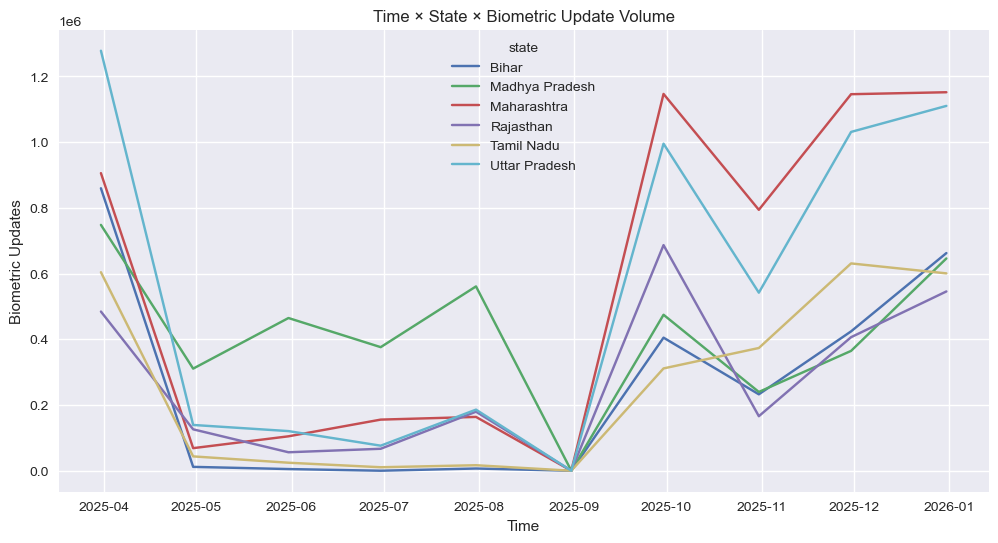

In [12]:
state_monthly = (
    df
    .set_index("date")
    .groupby("state")
    .resample("M")["biometric_total"]
    .sum()
    .reset_index()
)

top_states = (
    state_monthly.groupby("state")["biometric_total"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=state_monthly[state_monthly["state"].isin(top_states)],
    x="date",
    y="biometric_total",
    hue="state"
)

plt.title("Time × State × Biometric Update Volume")
plt.xlabel("Time")
plt.ylabel("Biometric Updates")
plt.show()


### Trivariate Analysis: Time × State × Biometric Update Volume

This visualization analyzes biometric update behavior across **time**, **states**,
and **update volume** simultaneously.

**Key observations:**

- Most states exhibit synchronized dips and spikes, indicating **system-wide
  temporal effects** rather than localized anomalies.
- States differ significantly in magnitude, even under the same time periods,
  highlighting the importance of **spatial comparison**.
- Sudden short-lived drops followed by recoveries likely reflect **operational or
  reporting changes**, not misuse.
- Sustained high volumes across consecutive months (e.g., Maharashtra, Uttar Pradesh)
  are more meaningful than isolated spikes and contribute more strongly to risk.

**Why this matters:**

This trivariate view allows the system to distinguish:
- Temporal patterns vs abnormal behavior
- State-specific deviations vs national trends
- Short-term noise vs persistent risk signals

These insights directly inform the **temporal and spatial components** of the
final risk score.


C:\Users\khage\AppData\Local\Temp\ipykernel_5964\3679313025.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["bio_demo_ratio"]


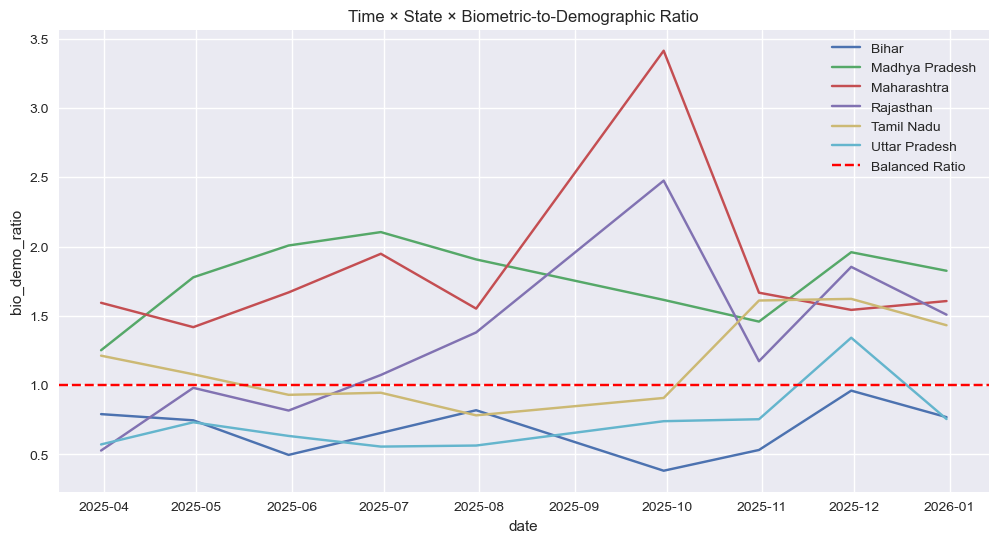

In [13]:
ratio_trend = (
    df
    .set_index("date")
    .groupby("state")
    .resample("M")["bio_demo_ratio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ratio_trend[ratio_trend["state"].isin(top_states)],
    x="date",
    y="bio_demo_ratio",
    hue="state"
)

plt.axhline(1, color="red", linestyle="--", label="Balanced Ratio")
plt.legend()
plt.title("Time × State × Biometric-to-Demographic Ratio")
plt.show()


### Trivariate Analysis: Time × State × Biometric-to-Demographic Ratio

This visualization tracks how the **biometric-to-demographic update ratio** evolves over time across selected states.  
The red dashed line at **ratio = 1** represents a **balanced update pattern**, where biometric and demographic updates occur in similar proportions.

#### Key Observations

- **Sustained imbalance in certain states**  
  States such as **Maharashtra and Rajasthan** consistently remain **above the balanced ratio**, indicating a persistent dominance of biometric updates. This suggests a **systematic behavioral pattern** rather than random variation.

- **Temporal spikes indicating abnormal shifts**  
  Maharashtra exhibits a **sharp spike around October**, where the ratio increases significantly. Such sudden deviations are strong indicators of **temporary operational changes, abnormal activity, or process stress**.

- **Stable baseline regions**  
  Bihar and Uttar Pradesh remain mostly **near or below the balanced ratio**, reflecting **stable and predictable update behavior**. These regions help establish a **normal behavioral baseline** for comparison.

- **Gradual behavioral transitions**  
  Tamil Nadu shows a **gradual transition from balanced to biometric-heavy updates** in later months, highlighting **slow behavioral drift rather than abrupt anomalies**.

#### Analytical Value

- This trivariate view captures **when, where, and how** update behavior changes.
- Persistent deviations are more meaningful than isolated spikes and form a **strong signal for risk assessment**.
- The biometric-to-demographic ratio acts as a **behavioral fingerprint**, enabling explainable identification of regions with unusual update composition.


### Age Group × Update Type × Geography

This analysis examines whether specific age groups disproportionately
contribute to biometric or demographic updates across states.


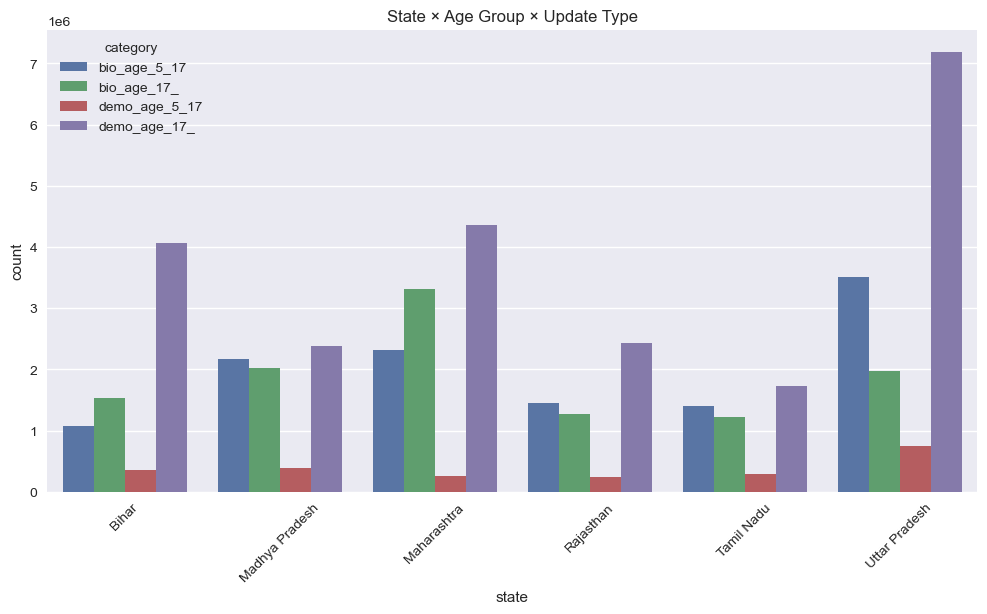

In [14]:
age_state = (
    df.groupby("state")[[
        "bio_age_5_17",
        "bio_age_17_",
        "demo_age_5_17",
        "demo_age_17_"
    ]]
    .sum()
    .reset_index()
)

age_state_melted = age_state.melt(
    id_vars="state",
    var_name="category",
    value_name="count"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=age_state_melted[age_state_melted["state"].isin(top_states)],
    x="state",
    y="count",
    hue="category"
)

plt.title("State × Age Group × Update Type")
plt.xticks(rotation=45)
plt.show()


### trivariate Analysis: State × Age Group × Update Type

This chart compares **biometric and demographic update volumes** across **states**, segmented by **age groups (5–17 and 18+)**.  
It helps understand **who is updating what, and where**, providing important demographic context to the risk intelligence system.

---

#### Key Observations

- **Adult demographic updates dominate across all states**  
  The **18+ demographic category** shows the highest update volumes in every state, which is expected since adult records require more frequent demographic changes (address, phone, name corrections).

- **Biometric updates are more prominent in the 5–17 age group**  
  States like **Uttar Pradesh, Maharashtra, and Madhya Pradesh** show relatively high biometric updates among children, aligning with expected biometric refresh cycles during growth years.

- **State-level scale differences are significant**  
  Uttar Pradesh clearly stands out with the **largest update volumes across all categories**, reflecting population scale rather than abnormal behavior. This reinforces the need for **relative, not absolute, anomaly detection**.

- **Balanced demographic structure in stable states**  
  States such as **Rajasthan and Tamil Nadu** show more proportional distributions across age groups and update types, indicating **operational consistency**.

---

#### Analytical Value

- This analysis provides **demographic grounding** to anomaly detection.
- It helps distinguish **legitimate high-volume behavior** (population-driven) from **suspicious deviations**.
- Age segmentation ensures that biometric-heavy regions are not incorrectly flagged when such patterns are **expected for certain age cohorts**.


In [15]:
df["z_ratio"] = (
    (df["bio_demo_ratio"] - df["bio_demo_ratio"].mean())
    / df["bio_demo_ratio"].std()
)

anomalies = df[
    (df["z_ratio"].abs() > 3)
]

anomalies[[
    "date", "state", "district", "pincode",
    "biometric_total", "demographic_total", "bio_demo_ratio"
]].head(10)


,date,state,district,pincode,biometric_total,demographic_total,bio_demo_ratio
1018,2025-11-25,Delhi,Central Delhi,110012,27,3,6.750000
1875,2025-11-16,Delhi,New Delhi,110021,8,0,8.000000
2286,2025-11-25,Delhi,South Delhi,110025,180,28,6.206897
2287,2025-11-25,Delhi,South Delhi,110025,180,28,6.206897
2548,2025-11-16,Delhi,South West Delhi,110028,15,1,7.500000
2876,2025-11-25,Delhi,East Delhi,110031,114,12,8.769231
2877,2025-11-25,Delhi,East Delhi,110031,114,12,8.769231
3063,2025-11-16,Delhi,East Delhi,110032,33,3,8.250000
3064,2025-11-16,Delhi,East Delhi,110032,33,3,8.250000
3065,2025-11-16,Delhi,East Delhi,110032,33,3,8.250000


**Insight:**  
Extreme deviations at the intersection of time, geography, and behavior
indicate high-risk update clusters — forming the analytical basis
for the downstream AI risk intelligence system.
